            Production
Month                 
1962-01-01         589
1962-02-01         561
1962-03-01         640
1962-04-01         656
1962-05-01         727
Production    0
dtype: int64


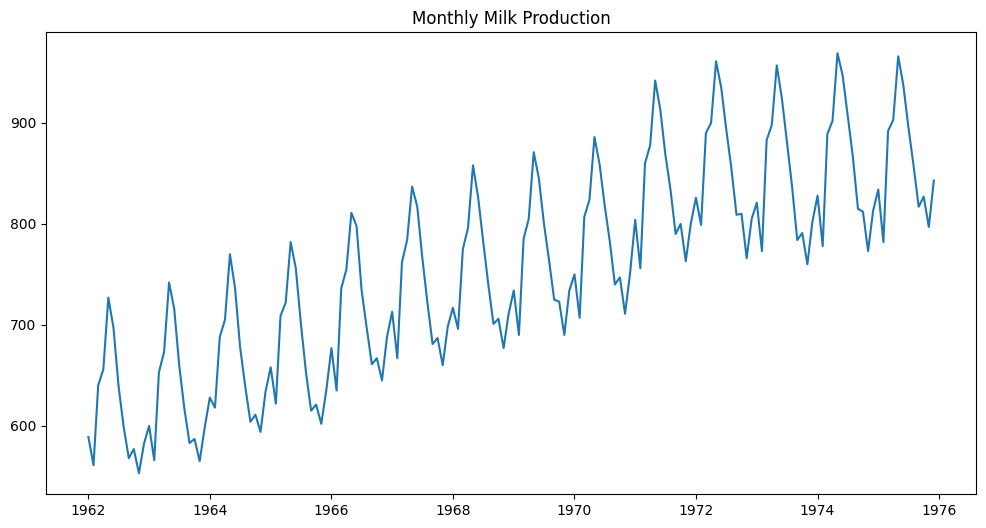

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step

Model Performance
RNN  -> RMSE: 21.432917359402524  MAE: 16.246845245361325  MAPE: 1.9166070309677077
LSTM -> RMSE: 35.66379541153979  MAE: 29.510486602783192  MAPE: 3.413647142730785
GRU  -> RMSE: 33.54532697107137  MAE: 26.704105377197255  MAPE: 3.1533016166161056


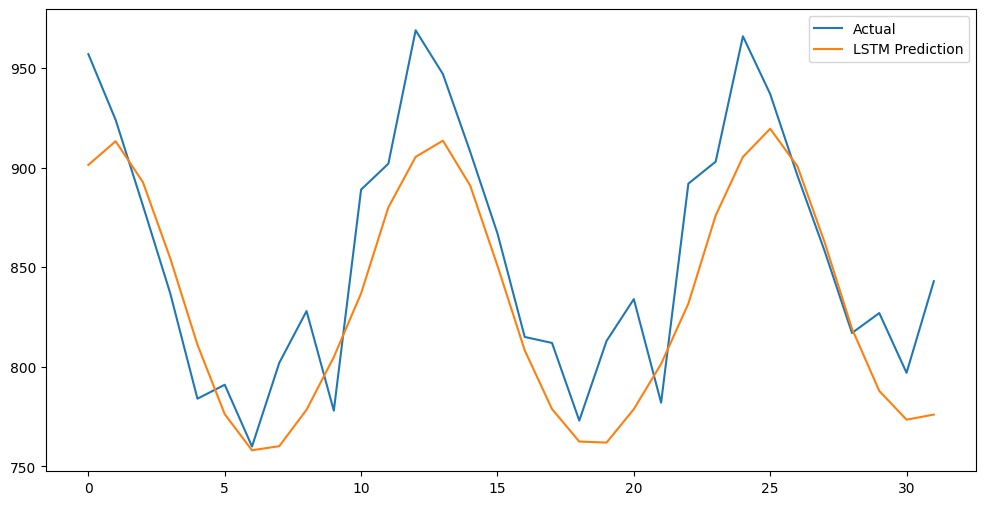

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


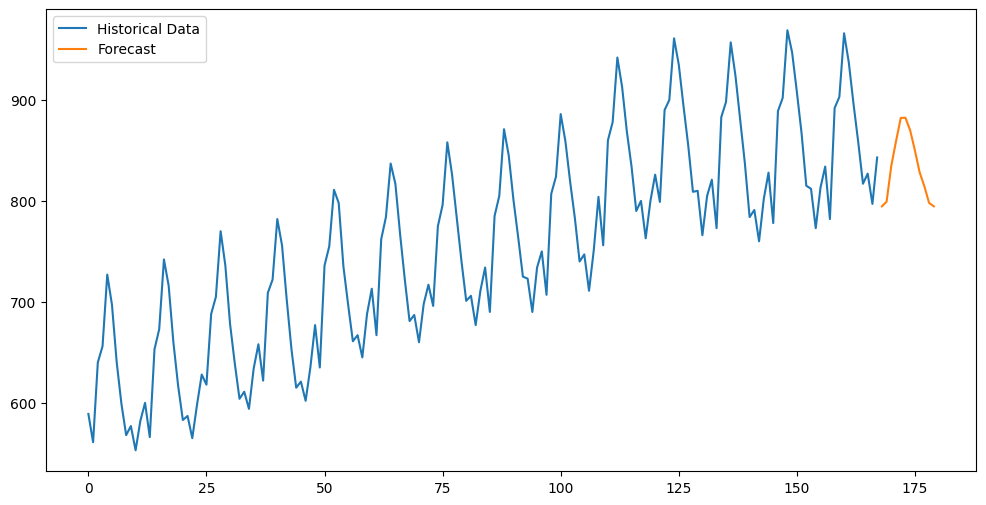

In [ ]:
# ===============================
# 1. Import Libraries
# ===============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU


# ===============================
# 2. Load Dataset
# ===============================
df = pd.read_csv("monthly_milk_production.csv")

df.columns = ['Month','Production']
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)


# ===============================
# 3. Exploratory Data Analysis
# ===============================
print(df.head())
print(df.isnull().sum())

plt.figure(figsize=(12,6))
plt.plot(df)
plt.title("Monthly Milk Production")
plt.show()


# ===============================
# 4. Normalize Data
# ===============================
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)


# ===============================
# 5. Create Time Series Sequences
# ===============================
def create_sequences(data, window_size=12):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)

window_size = 12
X, y = create_sequences(scaled_data, window_size)


# ===============================
# 6. Train-Test Split
# ===============================
split = int(len(X)*0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


# ===============================
# 7. Build Models
# ===============================

# ----- RNN -----
rnn_model = Sequential([
    SimpleRNN(50, activation='tanh', input_shape=(window_size,1)),
    Dense(1)
])
rnn_model.compile(optimizer='adam', loss='mse')
rnn_model.fit(X_train, y_train, epochs=50, batch_size=16, verbose=0)


# ----- LSTM -----
lstm_model = Sequential([
    LSTM(50, activation='tanh', input_shape=(window_size,1)),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.fit(X_train, y_train, epochs=50, batch_size=16, verbose=0)


# ----- GRU -----
gru_model = Sequential([
    GRU(50, activation='tanh', input_shape=(window_size,1)),
    Dense(1)
])
gru_model.compile(optimizer='adam', loss='mse')
gru_model.fit(X_train, y_train, epochs=50, batch_size=16, verbose=0)


# ===============================
# 8. Evaluation Function
# ===============================
def evaluate_model(model):

    pred = model.predict(X_test)

    pred_rescaled = scaler.inverse_transform(pred)
    y_rescaled = scaler.inverse_transform(y_test)

    rmse = np.sqrt(mean_squared_error(y_rescaled, pred_rescaled))
    mae = mean_absolute_error(y_rescaled, pred_rescaled)
    mape = np.mean(np.abs((y_rescaled - pred_rescaled)/y_rescaled))*100

    return pred_rescaled, y_rescaled, rmse, mae, mape


# Evaluate Models
rnn_pred, y_true, rnn_rmse, rnn_mae, rnn_mape = evaluate_model(rnn_model)
lstm_pred, _, lstm_rmse, lstm_mae, lstm_mape = evaluate_model(lstm_model)
gru_pred, _, gru_rmse, gru_mae, gru_mape = evaluate_model(gru_model)


print("\nModel Performance")
print("RNN  -> RMSE:", rnn_rmse, " MAE:", rnn_mae, " MAPE:", rnn_mape)
print("LSTM -> RMSE:", lstm_rmse, " MAE:", lstm_mae, " MAPE:", lstm_mape)
print("GRU  -> RMSE:", gru_rmse, " MAE:", gru_mae, " MAPE:", gru_mape)


# ===============================
# 9. Plot Predictions
# ===============================
plt.figure(figsize=(12,6))
plt.plot(y_true, label="Actual")
plt.plot(lstm_pred, label="LSTM Prediction")
plt.legend()
plt.show()


# ===============================
# 10. Forecast Next 12 Months
# ===============================
last_window = scaled_data[-window_size:]
future = []
current = last_window.copy()

for _ in range(12):
    pred = lstm_model.predict(current.reshape(1,window_size,1))
    future.append(pred[0][0])
    current = np.append(current[1:], pred)

future = scaler.inverse_transform(np.array(future).reshape(-1,1))


# ===============================
# 11. Plot Forecast
# ===============================
plt.figure(figsize=(12,6))
plt.plot(df.values, label="Historical Data")
plt.plot(range(len(df), len(df)+12), future, label="Forecast")
plt.legend()
plt.show()


In [ ]:
import requests

url = "https://raw.githubusercontent.com/plotly/datasets/master/monthly-milk-production-pounds.csv"
file_path = "monthly_milk_production.csv"

response = requests.get(url)
response.raise_for_status() # Raise an exception for bad status codes

with open(file_path, "wb") as f:
    f.write(response.content)

print(f"'{file_path}' downloaded successfully.")